In [2]:
import pandas as pd
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
import sys
import os
sys.path.append(os.path.abspath('..'))  # go one level up

from scripts.gpu_env import GpuEnv

# Load the data
workload_data = pd.read_csv('../data/workload_simulation.csv')

# Create environment
env = GpuEnv(workload_data)


In [3]:
from stable_baselines3 import PPO

# (Optional) Check if the environment follows Gym API
# check_env(env, warn=True)

# Define the PPO RL model
model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=1e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=10,
    gamma=0.95,
    verbose=1
)

# Train the model
model.learn(total_timesteps=5000)

# Save the model
model.save("../models/ppo_gpu_allocator")

print("✅ Training complete and model saved!")


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\SAMAD MEHNDI\AppData\Roaming\Python\Python312\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 24        |
|    ep_rew_mean     | -2.29e+03 |
| time/              |           |
|    fps             | 1021      |
|    iterations      | 1         |
|    time_elapsed    | 0         |
|    total_timesteps | 256       |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 24           |
|    ep_rew_mean          | -2.34e+03    |
| time/                   |              |
|    fps                  | 674          |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 512          |
| train/                  |              |
|    approx_kl            | 0.0006754317 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.26        |
|    explained_variance   | 0.000427     |
|    

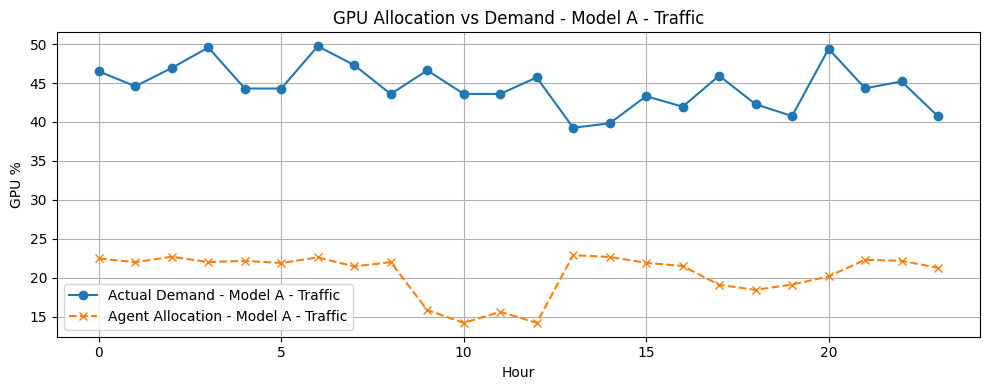

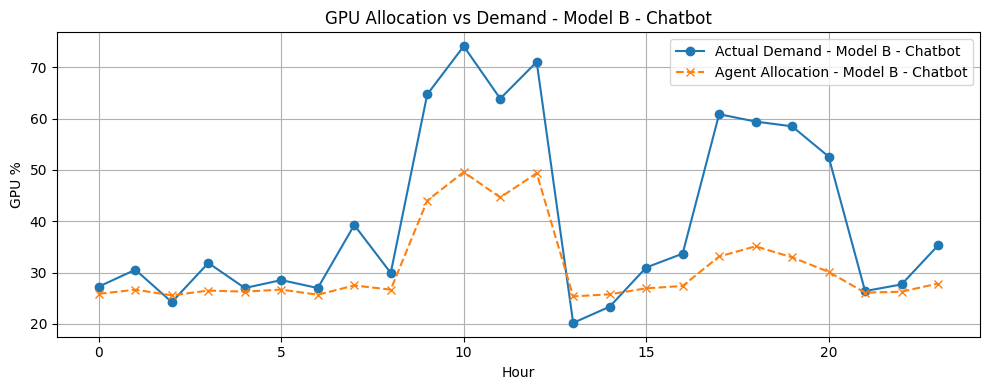

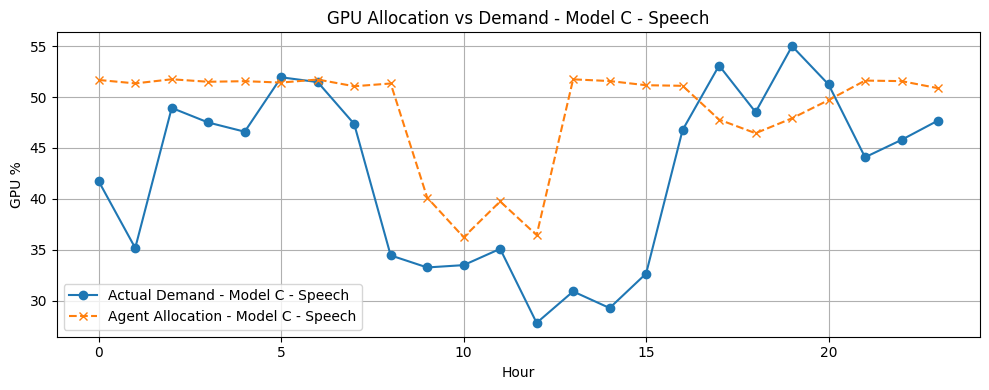

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stable_baselines3 import PPO
from scripts.gpu_env import GpuEnv

# Load the trained model
model = PPO.load("../models/ppo_gpu_allocator")

# Reload the environment
# workload_data = pd.read_csv('../data/workload_simulation.csv')
# env = GpuEnv(workload_data)

# Run a test episode
state, _ = env.reset(), None
allocations = []
demands = []
done = False

while not done:
    action, _ = model.predict(state, deterministic=True)
    demands.append(state)

    # Manually apply scaling + normalization (same as in env.step)
    action = np.clip(action, 0, 1)
    scaled = action * 100
    alloc = (scaled / scaled.sum()) * 100 if scaled.sum() > 0 else np.ones(3) * (100 / 3)
    allocations.append(alloc)

    state, _, done, _ = env.step(action)

# Convert lists to numpy arrays
allocations = np.array(allocations)
demands = np.array(demands)
hours = np.arange(len(allocations))

# Plot GPU allocation vs demand for each model
model_names = ['Model A - Traffic', 'Model B - Chatbot', 'Model C - Speech']

for i in range(3):
    plt.figure(figsize=(10, 4))
    plt.plot(hours, demands[:, i], label=f"Actual Demand - {model_names[i]}", marker='o')
    plt.plot(hours, allocations[:, i], label=f"Agent Allocation - {model_names[i]}", linestyle='--', marker='x')
    plt.title(f"GPU Allocation vs Demand - {model_names[i]}")
    plt.xlabel("Hour")
    plt.ylabel("GPU %")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [5]:
# Compute penalties
import numpy as np

allocations = np.array(allocations)
demands = np.array(demands)

under_allocation = np.maximum(0, demands - allocations)
over_allocation = np.maximum(0, allocations - demands)
total_penalty = np.abs(allocations - demands)

# Aggregate across all models and time
under_penalty_sum = np.sum(under_allocation)
over_penalty_sum = np.sum(over_allocation)
total_error_sum = np.sum(total_penalty)

print(f"🟥 Total Under-Allocation Penalty: {under_penalty_sum:.2f}")
print(f"🟦 Total Over-Allocation (Wasted GPU): {over_penalty_sum:.2f}")
print(f"✅ Total Absolute Error: {total_error_sum:.2f}")


🟥 Total Under-Allocation Penalty: 830.53
🟦 Total Over-Allocation (Wasted GPU): 172.97
✅ Total Absolute Error: 1003.50


In [6]:
import pandas as pd

df = pd.DataFrame({
    'Hour': np.arange(len(allocations)),
    'Model_A_Actual': demands[:, 0],
    'Model_A_Allocated': allocations[:, 0],
    'Model_B_Actual': demands[:, 1],
    'Model_B_Allocated': allocations[:, 1],
    'Model_C_Actual': demands[:, 2],
    'Model_C_Allocated': allocations[:, 2],
})

df.to_csv("../results/ppo_allocation_vs_demand.csv", index=False)
print("✅ CSV exported to results/ppo_allocation_vs_demand.csv")


✅ CSV exported to results/ppo_allocation_vs_demand.csv
